In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from mad.objs.constants import G0, titan_stage_1, titan_stage_2, EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig, SimulationInterface
from mad.objs.common_schemas import MovableObject, History
from mad.objs.projectiles import ProjectileConfig, Projectile
from mad.objs.missiles import MissileConfig, MissileStage, StageConfig, Guidance, BallisticMissile
from mad.logger import SourceLogger
from copy import deepcopy

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(-9.819649737724955))

In [4]:
titan_stage_1.update({"dry_mass":10_000, "propellant_mass":100_000, "Isp":285})
titan_stage_2.update({"dry_mass": 2_000, "propellant_mass": 20_000, "Isp": 300})

In [5]:
stage1 = MissileStage(StageConfig(**titan_stage_1))
stage2 = MissileStage(StageConfig(**titan_stage_2))


mis_pos = [earth.radius + 10, 10]
MissileTarget = MovableObject(position = [0.0, earth.radius + 10], name="Target")
guidance = Guidance(cruise_altitude=1, target=MissileTarget)
titan = BallisticMissile(MissileConfig(position = mis_pos, stages = [stage1, stage2], name="Titan I", guidance=guidance))

In [6]:
f"dV={titan.deltav:.2f} m/s, range={titan.ballistic_range(earth, gamma_deg=45)/1000:4.2f} km"

'dV=11015.15 m/s, range=13023.83 km'

In [7]:
dt = 1
active_objs = [titan]
inactive_objs = []
for t in range(20000):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)

    active_objs.extend(new_objects)

20:01:46 | INFO     | Missile      | Stage1 ran out of propellant at 149.00.
20:01:46 | INFO     | Missile      | Titan I - Stage1 separated at 149.00.
20:01:46 | INFO     | Simulation   | Stage1 added to Simulation.
20:01:46 | INFO     | Missile      | Stage2 ran out of propellant at 167.00.
20:01:46 | INFO     | Missile      | Titan I - Stage2 separated at 316.00.
20:01:46 | INFO     | Missile      | Titan I inactivated at 316.00.
20:01:46 | INFO     | Simulation   | Stage2 added to Simulation.
20:01:46 | INFO     | Projectile   | Stage1 landed on the ground!
20:01:46 | INFO     | Projectile   | Stage2 landed on the ground!


/app/src/mad/objs/missiles.py:155: RuntimeWarning: divide by zero encountered in scalar divide
  return np.arctan((self.deltav**2 - planet.mu / planet.radius) / self.deltav**2 * np.tan(sigma / 2))


In [8]:
def extract_history(objs:list):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)
        time = np.asarray(obj.history.time)

        posx, posz = pos[:, 0], pos[:, 1]
        velx, velz = vel[:, 0], vel[:, 1]

        altitude = np.sqrt(posx**2 + posz**2) - earth.radius
        velout = np.sqrt(velx**2 + velz**2)

        results[obj.name] = {"time": time, "altitude": altitude, "velocity":velout, "posx":posx, "posz":posz}

    return results

results = extract_history(active_objs)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

In [9]:
results["Stage2"]["posx"]

array([6571365.24306285, 6572534.14569626, 6573693.84397573, ...,
       4019820.29962156, 4019797.28617005, 4019774.32219925],
      shape=(1386,))

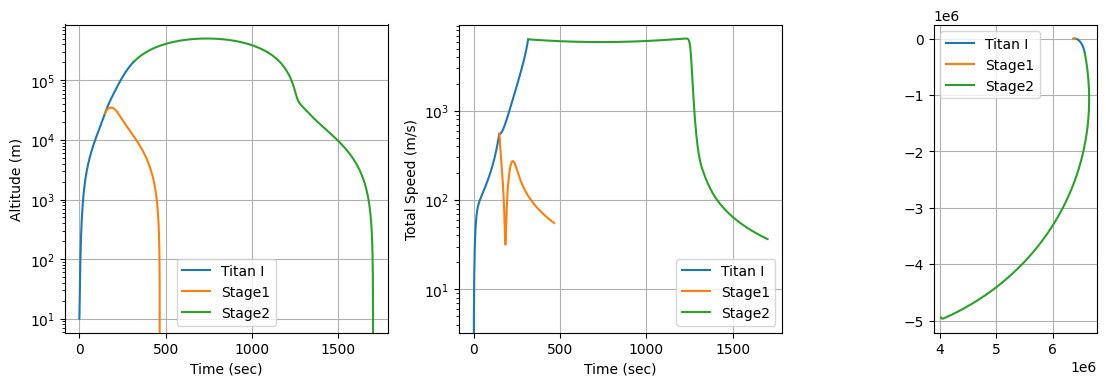

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

for obj, result in results.items():

    ax[0].semilogy(result["time"], result["altitude"], label=obj)
    ax[1].semilogy(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["posx"], result["posz"], label=obj)


ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (m)")
ax[0].grid()
ax[0].legend()

theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].set_aspect("equal")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)